# Whats Cooking Classification: Predicting cuisine based on recipe text data

Project adapted from Professor Anthony Breitzman at Rowan University, Web and Text Mining 2026.

Dataset info: The following models are trained used the cooking_trainfile.json file. It is a text file comprising of (many) rows of recipes, each with a unique id, an associated cuisine (ex: greek) and a list of ingredients comprising that recipe. 

The goal is that with this data, I can train my model(s) to predict cuisines based on the list of ingredients. After training my models, I will then test them with the cooking_testfile.json, which gives ingredients but not cuisine info. 

 I intend to do a lot of pre-processing, exploratory analysis, model selection/comparison, error analysis and evaluation.

 Thanks for reading!

# How should I measure success in my models?

Accuracy - what percentage of all recipes recieved the correct cuisine. Important, but also could be easily skewed if, for example, it is incredibly accurate with Italian cuisine but horribly inaccurate with Brazilian. Italian recipes could outnumber Brazilian, so even if accuracy is great, it shouldn't be my only decision metric.

Precision and Recall - in a binary classification problem, precision and recall are easier to define. In this multiclass assignment, each cuisine is treated as the positive class against all other classes. This makes it harder to justify prioritizing one over the other.

Macro F1 - balances precision/recall, calculates an F1 score for each class (cuisine) separately and takes the average. This will be my **primary success metric.**

Weighted F1 - gives larger cuisines more influence. Comparing this to macro F1 will be very informative to see how smaller cuisines do against larger ones. If similar, then performance is relatively consistent across cuisines (great), - if higher, then smaller cuisines are likely doing worse.

In [27]:
import sys
print(sys.version)

3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:26:47) [MSC v.1942 64 bit (AMD64)]


In [43]:
# Import the required libraries 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import json

# 1. Read Data



In [44]:
def read_dataset(path):
  return json.load(open(path)) 

data = read_dataset('data/cooking_trainfile.json')

Convert everything to lowercase for consistency (ex: Rice and rice should be treated the same way)

In [45]:
def generate_text(data):
  text_data = [" ".join(doc['ingredients']).lower() for doc in data]
  return text_data 

In [46]:
X = generate_text(data)
Y = [doc['cuisine'] for doc in data]

In [47]:
for i in range(5):
    print(Y[i],'|',X[i],'\n')

greek | romaine lettuce black olives grape tomatoes garlic pepper purple onion seasoning garbanzo beans feta cheese crumbles 

filipino | eggs pepper salt mayonaise cooking oil green chilies grilled chicken breasts garlic powder yellow onion soy sauce butter chicken livers 

indian | water vegetable oil wheat salt 

indian | black pepper shallots cornflour cayenne pepper onions garlic paste milk butter salt lemon juice water chili powder passata oil ground cumin boneless chicken skinless thigh garam masala double cream natural yogurt bay leaf 

jamaican | plain flour sugar butter eggs fresh ginger root salt ground cinnamon milk vanilla extract ground ginger powdered sugar baking powder 



Divide into training and validation sets. In the interest preserving class proportion, I will include the line "stratify=Y"

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    Y, 
    test_size=0.20, 
    random_state=42,
    stratify=Y # ensures that each cusisine has approx. the same proportion in the training and validation sets
)

In [49]:
print(len(X_train),len(y_train),len(X_test),len(y_test))

25454 25454 6364 6364


Verifying that straification preserved class distribution

In [53]:
print("Entire Dataset")
print(pd.Series(Y).value_counts(normalize=True))

print("\nTraining Set")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTesting Set")
print(pd.Series(y_test).value_counts(normalize=True))

Entire Dataset
italian         0.198253
mexican         0.162738
southern_us     0.108775
indian          0.074298
chinese         0.066660
french          0.066472
thai            0.038657
cajun_creole    0.038626
japanese        0.036426
greek           0.029637
spanish         0.025206
vietnamese      0.020806
british         0.020429
korean          0.020240
moroccan        0.019392
filipino        0.019329
irish           0.016626
jamaican        0.013232
brazilian       0.012131
russian         0.012069
Name: proportion, dtype: float64

Training Set
italian         0.198240
mexican         0.162725
southern_us     0.108784
indian          0.074291
chinese         0.066669
french          0.066473
thai            0.038658
cajun_creole    0.038619
japanese        0.036419
greek           0.029622
spanish         0.025222
vietnamese      0.020822
british         0.020429
korean          0.020233
moroccan        0.019408
filipino        0.019329
irish           0.016618
jamaican     

Before I continue cleaning data I would like to do some Exploratory Data Analysis to better understand what I'm working with. This will help me with cleaning, preprocessing, modeling and analysis.

# 2. Exploratory Data Analysis

In [57]:
cuisine_counts = pd.Series(Y).value_counts()
cuisine_distribution = pd.DataFrame({
    "Count": pd.Series(Y).value_counts(),
    "Percentage": (pd.Series(Y).value_counts(normalize=True) * 100).round(2)
})

print(cuisine_distribution)
print("\ntotal recipes:", cuisine_counts.sum())

              Count  Percentage
italian        6308       19.83
mexican        5178       16.27
southern_us    3461       10.88
indian         2364        7.43
chinese        2121        6.67
french         2115        6.65
thai           1230        3.87
cajun_creole   1229        3.86
japanese       1159        3.64
greek           943        2.96
spanish         802        2.52
vietnamese      662        2.08
british         650        2.04
korean          644        2.02
moroccan        617        1.94
filipino        615        1.93
irish           529        1.66
jamaican        421        1.32
brazilian       386        1.21
russian         384        1.21

total recipes: 31818


Most represented cuisines: Italian, Mexican, Southern_US

Least represented: Jamaican, Brazilian, Russian

Visualization:

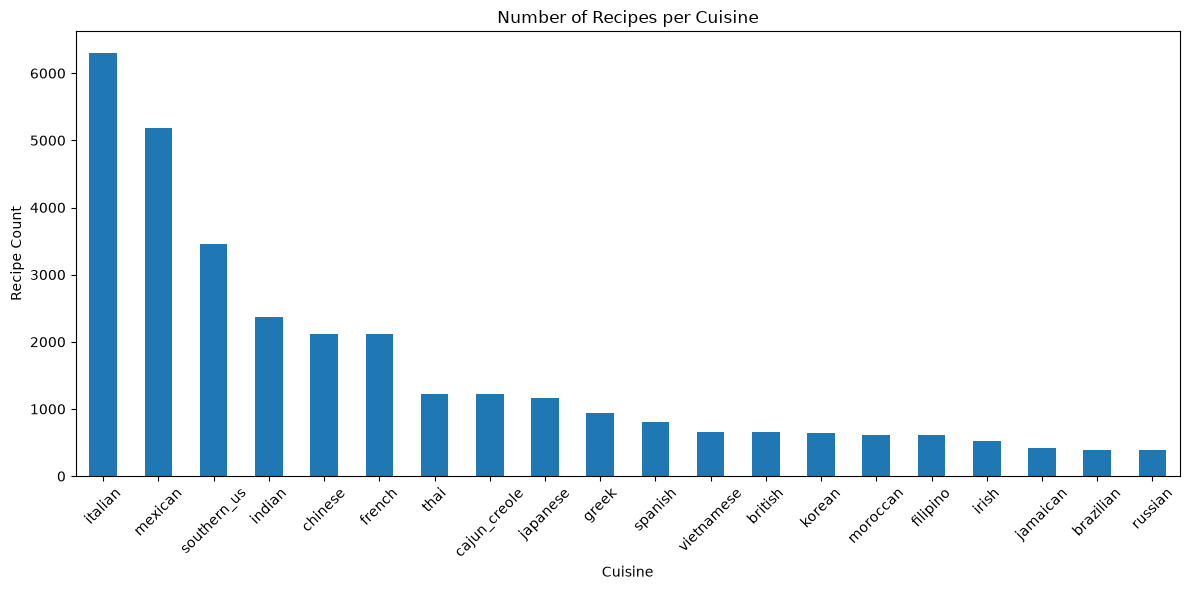

In [51]:
plt.figure(figsize=(12,6))
cuisine_counts.plot(kind="bar")

plt.title("Number of Recipes per Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Recipe Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [35]:
# Decided to use reg ex library (https://docs.python.org/3/library/re.html)
# Wanted to do this to "group words"
# For example, I noticed a couple ingredients consist of two words, but they 
# aren't connected via underscore, so they're treated differently.
# ex: soy and sauce should be one token
# Also, some ingredients are the same thing. Like cilantro and coriander.


import re

_PATTS = [
    # Cilantro is coriander, decided to group these two
    (re.compile(r"\bcoriander\b", re.I), "cilantro"),
    # scallions, spring onions, green onions should all be grouped into green_onion
    (re.compile(r"\b(scallions?|spring\s+onions?|green\s+onions?)\b", re.I), "green_onion"),
    # soy and sauce should be one phrase, soy_sauce
    (re.compile(r"\bsoy\s+sauce\b", re.I), "soy_sauce"),

    ## *I noticed accuracy for Jamaican was quite low (.15 accuracy on CM, confused
    ## with korean and russian, so I added some re.compiles for its cuisine
    (re.compile(r"\bjerk(\s+seasoning)?\b", re.I), "jerk_seasoning"),
  
    
]




In [11]:

def preprocess(s: str) -> str:
    s = s.lower()
    for rx, rep in _PATTS:
        s = rx.sub(rep, s)
    return s

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Built a modeling pipeleine, the TfidfVectorizer turns text numeric
# min_df = 4, so this ignores words that appear in fewer than 4 documents 
# min_df of 4 gave me the best test accuracy and had the best CM 
# Linear SVC (support vector classification)
# implements the preprocessor function from last cell
# ngram_range of 1,1 (1,2 yielded worse results)
# * class weight balanced because I noticed that cuisines like Italian or Thai had high accuracy,
# but other cuisines were very inaccurately matched
pipe = Pipeline([
    ("vec", TfidfVectorizer(
        preprocessor = preprocess,                 
        token_pattern=r"(?u)\b\w[\w_]+\b",          
        min_df=1, ngram_range=(1,1)
    )),
    ("clf", LinearSVC(C=1.0))
])

param_grid = {"clf__C": [0.5, 1.0, 2.0]}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Test accuracy:", gs.score(X_test, y_test))


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params: {'clf__C': 0.5}
Test accuracy: 0.7969830295411691


In [12]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
y_pred = gs.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))
print("Macro Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("Macro Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))


Accuracy: 0.7969830295411691
Macro F1: 0.7284015787947627
Weighted F1: 0.7930599360062223
Macro Precision: 0.7689485006442551
Macro Recall: 0.7012211642619266


In [13]:
import warnings
warnings.filterwarnings("ignore")  #not a great idea in general, but it cleans up the output when using scikit-learn
#obviously anything that triggers an error won't get ignored

from sklearn.neighbors import KNeighborsClassifier

In [14]:
#let's look at 20 predictions

for i in range(20):
    print(X_test[i],'|',y_test[i],'|',y_pred[i],'\n')

black pepper chopped green bell pepper garlic cloves italian salad dressing bouillon cube long-grain rice olive oil flavored cooking spray olive oil chopped onion boneless skinless chicken breast halves turkey breakfast sausage chopped celery hot water sliced green onions | cajun_creole | italian 

fresh cilantro salt stewed tomatoes chopped fresh chives serrano pepper garlic | mexican | mexican 

coriander seeds salt ghee saffron threads whole milk yoghurt cumin seed milk garlic fresh lemon juice fresh ginger root cayenne pepper chicken thighs | indian | indian 

mayonaise flour tortillas olive oil chipotle peppers shredded cheddar cheese salt asparagus | mexican | mexican 

bread giblet ground cayenne pepper oysters salt cooked white rice pepper chopped celery chopped parsley vegetable oil chopped onion | cajun_creole | cajun_creole 

seasoning pork sirloin chops pepper panko breadcrumbs eggs salt flour canola oil | korean | japanese 

green onions chili shredded cheddar cheese cream

In [15]:
class_names =[]
for i in range(len(y_test)):
    if y_test[i] not in class_names:
        class_names.append(y_test[i])

In [16]:
import matplotlib.pyplot as plt
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

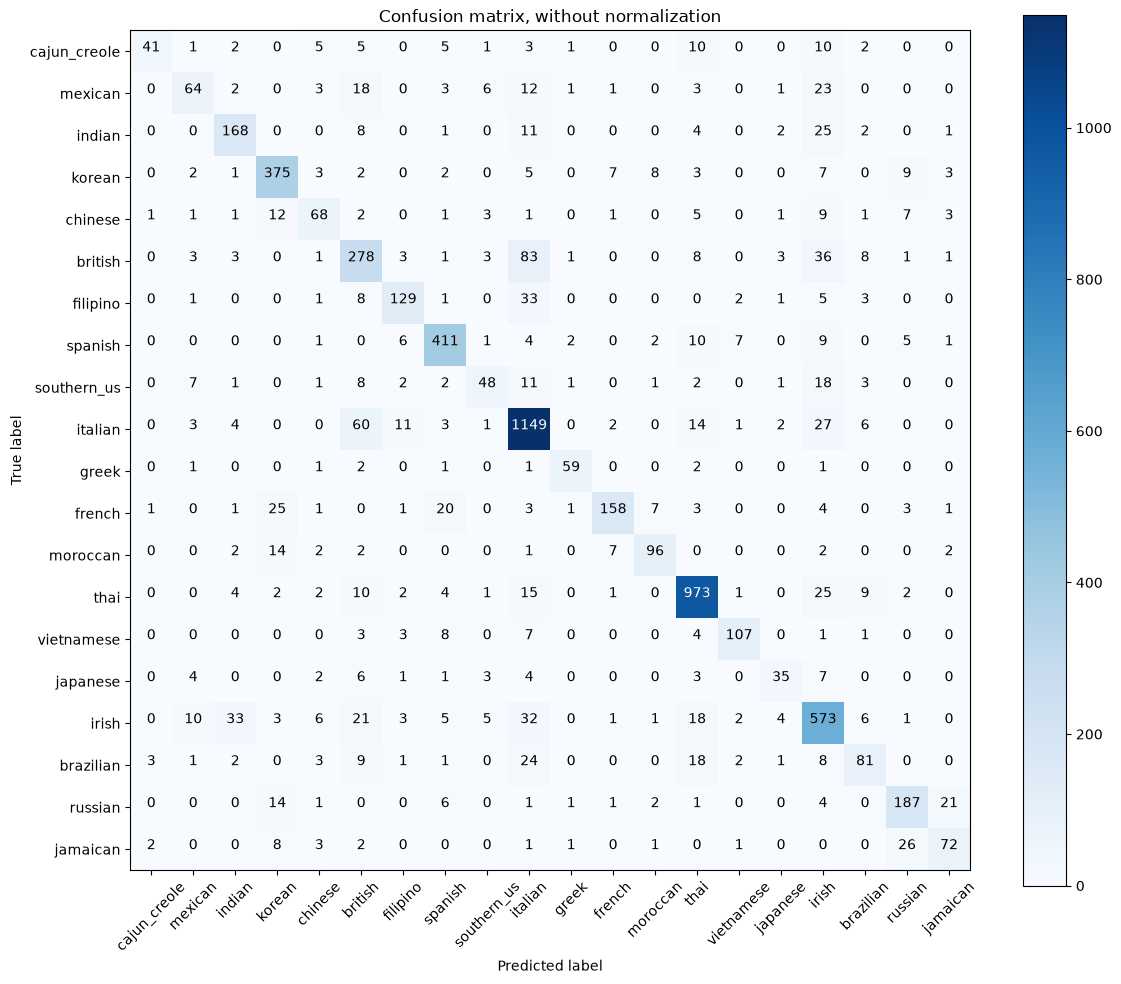

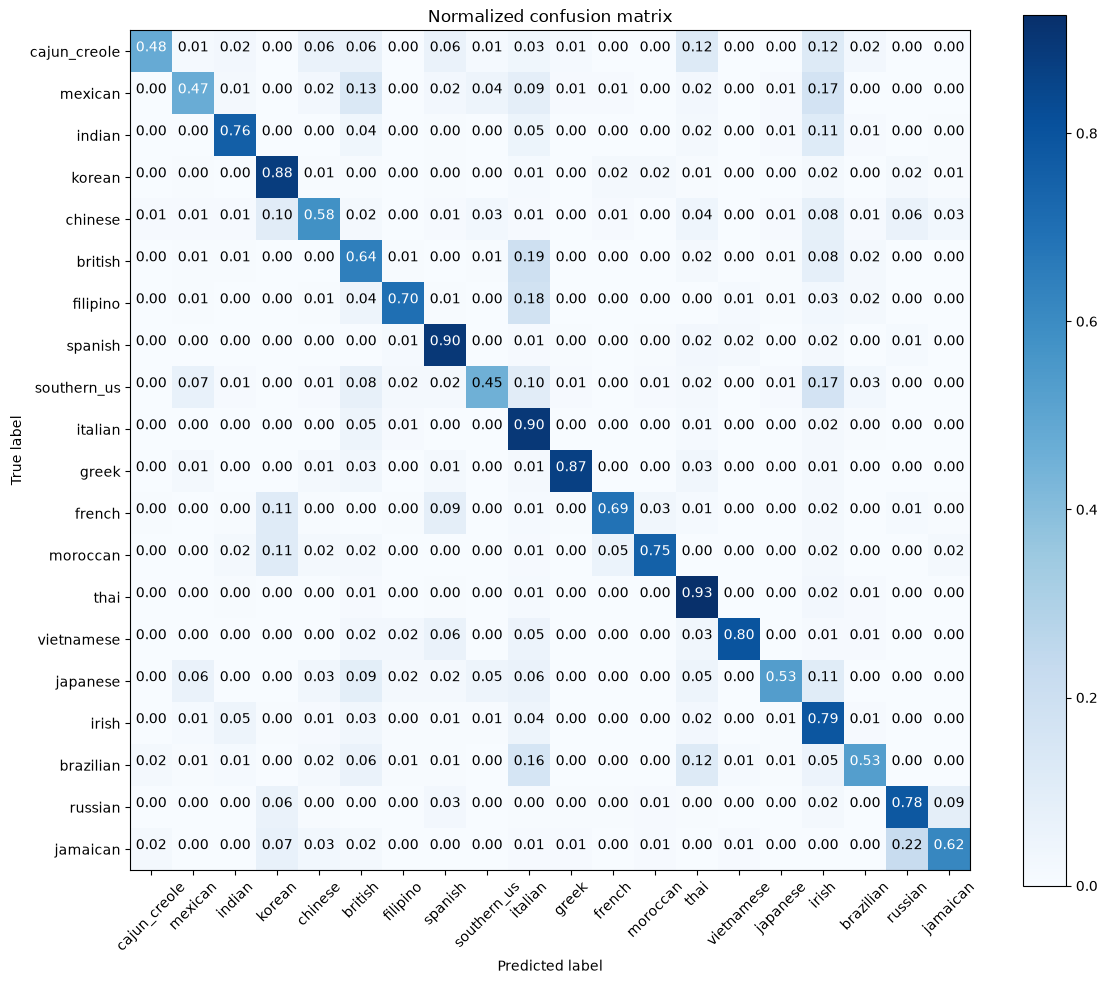

In [17]:


from sklearn.metrics import confusion_matrix
import numpy as np

cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names,
                      title='Confusion matrix, without normalization')

#plt.savefig("figure1.pdf", dpi="figure")
# Plot normalized confusion matrix
plt.figure(figsize=(12, 10))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=True,
                      title='Normalized confusion matrix')

#plt.savefig("figure2.pdf", dpi="figure")
plt.show()

In [18]:
import json, pandas as pd
import csv

with open("data/cooking_testfile.json", "r", encoding="utf-8") as f:
    data = json.load(f)

ids   = [d["id"] for d in data]
texts = [", ".join(d["ingredients"]) for d in data]  # <-- was the bug

best = gs.best_estimator_
pred = best.predict(texts)
out = pd.DataFrame({"id": ids, "cuisine": pred})

# Creates new output file, uncomment to download
#out.to_csv("data/cooking_output.csv", index=False)
print("Wrote cooking_output.csv with", len(out), "rows; last id:", out.iloc[-1,0])



Wrote cooking_output.csv with 7955 rows; last id: 905668
